# Offset Deep Dive — DRAM M1 CU CMP

**목적:** `algorithm_new/Common/OFFSET.py`의 함수들을 단계별로 직접 호출하며 OFFSET 학습값이 어떻게 만들어지는지 이해한다.

---
## Offset 알고리즘 전체 흐름

```
load_rr_data()         ← MongoDB에서 RR B1/B0 계수 로드 → merge_df에 컬럼 추가
     │
     ▼
compute_offset()       ← 실측 RR vs 예측 RR 차이로 OFFSET(연마시간 보정량) 계산
     │   RR_actual = (Pre_Target − Post_Thk) / Pol_Time
     │   RR_Pad    = Pad_Para × B1 + B0          ← 패드 마모 기반 예측
     │   OFFSET    = delta/RR_actual − delta/RR_Pad
     │   → Idle_/Layer_ 그룹: 5건 이상 → 장비별 평균 저장
     │
     ▼
compute_lc_offset()    ← LC_ 패턴(패드교체 직후) 별도 집계 저장
     │   Offset_Group='Y': 장비번호 제거 → recipe_group 단위 평균
     │
     ▼
MongoDB 저장           ← MICO_OFFSET_{Lot}_{Oper}_{Fab}
```

In [16]:
import os, sys
from pathlib import Path

# ── Django ORM async 허용 ─────────────────────────────────────────────
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = '1'

# ── sys.path 설정 ─────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.').resolve()
MICO_DIR     = NOTEBOOK_DIR.parent
ALGO_DIR     = MICO_DIR / 'algorithm_new'
sys.path.insert(0, str(MICO_DIR))
sys.path.insert(0, str(ALGO_DIR))

# ── pymongo 전역 Mock (실서버 MongoDB 없이 실행) ──────────────────────
import pymongo as _pymongo
from unittest.mock import MagicMock

_mock_col = MagicMock()
_mock_col.find.return_value           = iter([])
_mock_col.list_collection_names.return_value = []
_mock_db  = MagicMock()
_mock_db.__getitem__.return_value     = _mock_col
_mock_db.list_collection_names.return_value  = []
_mock_mc  = MagicMock()
_mock_mc.__getitem__.return_value     = _mock_db
_mock_mc.close.return_value           = None
_pymongo.MongoClient = MagicMock(return_value=_mock_mc)

# ── Django setup ──────────────────────────────────────────────────────
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
import django
django.setup()

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']      = 110
plt.rcParams['font.size']       = 10
plt.rcParams['axes.titlesize']  = 11
plt.rcParams['axes.labelsize']  = 10

COLORS = ['#4C96D7', '#E87040', '#5BAD8F', '#C65DA0', '#8B7DC8']

from Common.Get_Data        import Get_data
from Common.OFFSET          import OFFSET_Get
from Common.MongoDB_Control import _STORE

## 파라미터 확인

`baseinfoGetData()`로 SQLite DB에서 Set-up 정보를 조회한다.
Offset 계산은 **FB_Type=TIME** 행만 사용한다.

In [18]:
mico = Get_data.baseinfoGetData('DRAM', 'M1 CU CMP')

# Offset은 FB_Type=TIME 행만 사용 (Module_Get.compute_offset 과 동일)
mico_time = mico[mico['FB_Type'] == 'TIME'].copy()
key       = mico_time.iloc[0]

APC_Para     = key['APC_Para']
Thk_Para     = key['Thk_Para']
Recipe_ID    = key['Recipe_ID']
Oper_Code    = key['Oper_Code']
Oper_Desc    = key['Oper_Desc']
Fab          = key['Fab']
Lot_Code     = key['Lot_Code']
Pre_Target   = float(key['Pre_Target'])
Target       = float(key['Target'])
Offset_Group = key['Offset_Group']

# APC Para → Pol_Time 컬럼, Pad 소모품 컬럼
Pol_Para = Get_data.APCParaGet(APC_Para, pol_type=3)   # ['P3']
Pad_Para = Get_data.PadParaGet(APC_Para)                # 'AMAT_PAD_3'

DEMO_EQP = 'KCMP43'
DEMO_RCP = Recipe_ID

print('── Set-up 파라미터 ──────────────────────────────────')
print(f'  APC_Para     : {APC_Para}')
print(f'  Thk_Para     : {Thk_Para}')
print(f'  Recipe_ID    : {Recipe_ID}')
print(f'  Pre_Target   : {Pre_Target} Å    Target: {Target} Å')
print(f'  Pol_Para     : {Pol_Para}   (Pol_Time 컬럼)')
print(f'  Pad_Para     : {Pad_Para}   (PAD 소모품 컬럼)')
print(f'  Offset_Group : {Offset_Group}  (Y=recipe_group 단위 그룹화)')
print()
print(f'  delta = Pre_Target - Target = {Pre_Target - Target:.0f} Å')
print(f'  → OFFSET = delta/RR_actual - delta/RR_Pad (초 단위 연마 시간 보정량)')
print()
print(f'대표 장비: {DEMO_EQP} / {DEMO_RCP}')

── Set-up 파라미터 ──────────────────────────────────
  APC_Para     : P3
  Thk_Para     : AMAT_POST_OCD_AVG
  Recipe_ID    : E2_M1CU_R12_TSV.CAS
  Pre_Target   : 2350.0 Å    Target: 1900.0 Å
  Pol_Para     : ['P3']   (Pol_Time 컬럼)
  Pad_Para     : AMAT_PAD_3   (PAD 소모품 컬럼)
  Offset_Group : Y  (Y=recipe_group 단위 그룹화)

  delta = Pre_Target - Target = 450 Å
  → OFFSET = delta/RR_actual - delta/RR_Pad (초 단위 연마 시간 보정량)

대표 장비: KCMP43 / E2_M1CU_R12_TSV.CAS


## 준비 — `load_rr_data()` : RR B1/B0 계수 로드

Offset 계산에는 **RR 학습값(B1/B0)** 이 필요하다.  
`load_rr_data()`는 MongoDB의 RR 컬렉션에서 B1/B0를 읽어 `merge_df`에 merge_asof로 결합한다.

```python
# _get_b_coef() — weighted 우선, 없으면 일반 계수 사용
if pd.isna(row['b1_weighted']):
    return b1, b0
else:
    return b1_weighted, b0_weighted

# RR_Table pivot → eqp_id/recipe_id 기준 merge_asof
# → merge_df에 P3_B1, P3_B0 컬럼 추가
```

**이 노트북에서는 MongoDB 없이** RR 결과를 아래와 같이 직접 구성한다.

In [19]:
# ── 실제 데이터 로드 ───────────────────────────────────────────────────
merge_df = pd.read_csv(
    ALGO_DIR / 'merge_df_sample.csv',
    parse_dates=['Date', 'pre_oper_time']
)
merge_df['IDLE'] = merge_df['IDLE'].fillna('')

# ── _get_b_coef() 동작 시연 ───────────────────────────────────────────
# load_rr_data()가 MongoDB에서 받아오는 RR_Table 구조 (예시)
eqp_list = merge_df['eqp_id'].unique()
# 이전 RR deep-dive 노트북에서 산출된 값 (KCMP41~45 실제 결과)
rr_result_mock = [
    {'EQ':'KCMP43','Recipe_ID':Recipe_ID,'APC_Para':APC_Para,'Date':pd.Timestamp('2026-04-14'),'b1':'-0.0137','b0':'19.8651','b1_weighted':'-0.0307','b0_weighted':'21.1675'},
    {'EQ':'KCMP42','Recipe_ID':Recipe_ID,'APC_Para':APC_Para,'Date':pd.Timestamp('2026-04-14'),'b1':'-0.0112','b0':'19.1610','b1_weighted': None,     'b0_weighted': None},
    {'EQ':'KCMP41','Recipe_ID':Recipe_ID,'APC_Para':APC_Para,'Date':pd.Timestamp('2026-04-14'),'b1': '0.0175','b0':'19.5028','b1_weighted':'-0.0105','b0_weighted':'20.0545'},
    {'EQ':'KCMP44','Recipe_ID':Recipe_ID,'APC_Para':APC_Para,'Date':pd.Timestamp('2026-04-14'),'b1':'-0.0104','b0':'19.5762','b1_weighted':'-0.0316','b0_weighted':'20.1153'},
    {'EQ':'KCMP45','Recipe_ID':Recipe_ID,'APC_Para':APC_Para,'Date':pd.Timestamp('2026-04-14'),'b1':'-0.0277','b0':'19.4525','b1_weighted': '0.0414','b0_weighted':'17.9843'},
]
RR_Table = pd.DataFrame(rr_result_mock)
RR_Table['Date'] = pd.to_datetime(RR_Table['Date'])

print('── RR_Table (MongoDB에서 로드된 구조) ───────────────────────────')
display(RR_Table[['EQ','Recipe_ID','APC_Para','b1','b0','b1_weighted','b0_weighted']])

# ── _get_b_coef() 실제 함수 호출 ─────────────────────────────────────
RR_Table[['b1_new','b0_new']] = RR_Table.apply(OFFSET_Get._get_b_coef, axis=1)
print()
print('── _get_b_coef() 결과: weighted 우선 선택 ───────────────────────')
display(RR_Table[['EQ','b1','b0','b1_weighted','b0_weighted','b1_new','b0_new']])

── RR_Table (MongoDB에서 로드된 구조) ───────────────────────────


,EQ,Recipe_ID,APC_Para,b1,b0,b1_weighted,b0_weighted
0,KCMP43,E2_M1CU_R12_TSV.CAS,P3,-0.0137,19.8651,-0.0307,21.1675
1,KCMP42,E2_M1CU_R12_TSV.CAS,P3,-0.0112,19.1610,None,None
2,KCMP41,E2_M1CU_R12_TSV.CAS,P3,0.0175,19.5028,-0.0105,20.0545
3,KCMP44,E2_M1CU_R12_TSV.CAS,P3,-0.0104,19.5762,-0.0316,20.1153
4,KCMP45,E2_M1CU_R12_TSV.CAS,P3,-0.0277,19.4525,0.0414,17.9843



── _get_b_coef() 결과: weighted 우선 선택 ───────────────────────


,EQ,b1,b0,b1_weighted,b0_weighted,b1_new,b0_new
0,KCMP43,-0.0137,19.8651,-0.0307,21.1675,-0.0307,21.1675
1,KCMP42,-0.0112,19.1610,None,None,-0.0112,19.1610
2,KCMP41,0.0175,19.5028,-0.0105,20.0545,-0.0105,20.0545
3,KCMP44,-0.0104,19.5762,-0.0316,20.1153,-0.0316,20.1153
4,KCMP45,-0.0277,19.4525,0.0414,17.9843,0.0414,17.9843


── pivot 결과 → P3_B1, P3_B0 컬럼 생성 ────────────────────────


,eqp_id,recipe_id,P3_B1,P3_B0
0,KCMP41,E2_M1CU_R12_TSV.CAS,-0.0105,20.0545
1,KCMP42,E2_M1CU_R12_TSV.CAS,-0.0112,19.1610
2,KCMP43,E2_M1CU_R12_TSV.CAS,-0.0307,21.1675
3,KCMP44,E2_M1CU_R12_TSV.CAS,-0.0316,20.1153
4,KCMP45,E2_M1CU_R12_TSV.CAS,0.0414,17.9843



merge_asof 후: 20844행
P3_B1 유효 건수: 5817
P3_B1 샘플 (KCMP43/TSV): -0.0307
P3_B0 샘플 (KCMP43/TSV): 21.1675


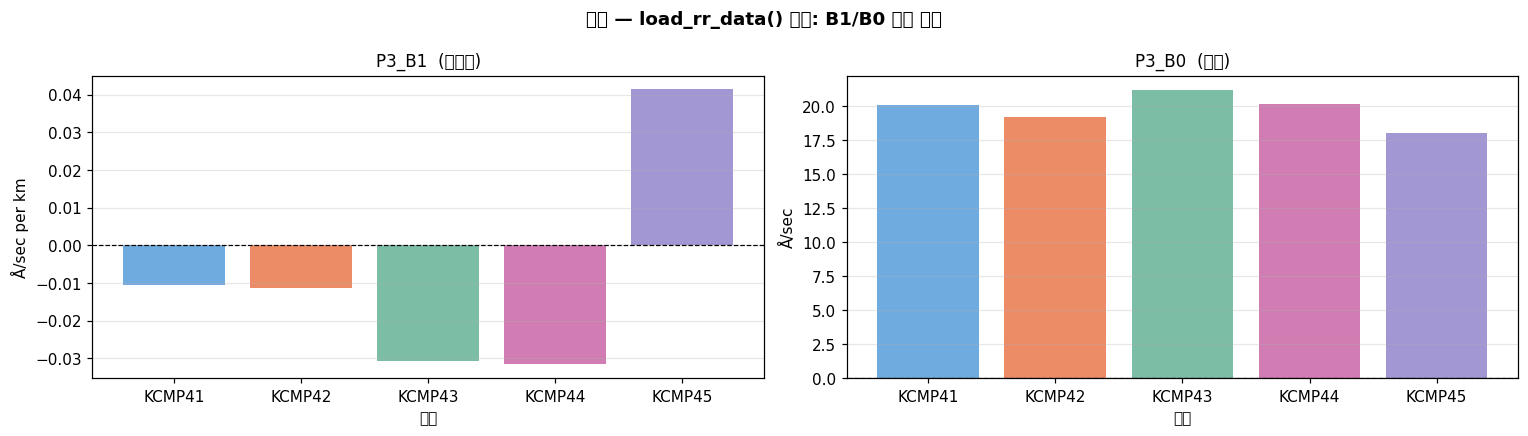

In [20]:
# ── load_rr_data() 내부: pivot → merge_asof 과정 시연 ────────────────
# (실제 함수는 MongoDB에서 RR_Table을 읽지만 여기서는 위의 mock RR_Table 사용)

RR_tbl = RR_Table[RR_Table['APC_Para'].isin([APC_Para])].copy()
RR_tbl.rename(columns={'EQ':'eqp_id','Recipe_ID':'recipe_id','APC_Para':'input_name'}, inplace=True)
RR_tbl['b1_new'] = pd.to_numeric(RR_tbl['b1_new'], errors='coerce')
RR_tbl['b0_new'] = pd.to_numeric(RR_tbl['b0_new'], errors='coerce')

pivot_col = ['b1_new','b0_new']
RR_pivot  = pd.pivot_table(
    data    = RR_tbl,
    index   = ['Date','eqp_id','recipe_id'],
    columns = ['input_name'],
    values  = pivot_col
).reset_index()
RR_pivot.columns = [
    i[1]+'_B1' if 'b1' in i[0] else
    i[1]+'_B0' if 'b0' in i[0] else
    i[0]
    for i in RR_pivot.columns
]

print('── pivot 결과 → P3_B1, P3_B0 컬럼 생성 ────────────────────────')
display(RR_pivot[['eqp_id','recipe_id','P3_B1','P3_B0']])

# ── merge_asof로 merge_df에 B1/B0 결합 ───────────────────────────────
merge_df_off = merge_df.rename(columns={'request_dtts':'Date'}).copy()
merge_df_off['Date'] = pd.to_datetime(merge_df_off['Date'])
merge_df_off = pd.merge_asof(
    merge_df_off.sort_values('Date'),
    RR_pivot.sort_values('Date'),
    on='Date', by=['eqp_id','recipe_id']
)

b1_col = f'{APC_Para}_B1'
b0_col = f'{APC_Para}_B0'
print()
print(f'merge_asof 후: {len(merge_df_off)}행')
print(f'{b1_col} 유효 건수: {merge_df_off[b1_col].notna().sum()}')
_demo = merge_df_off[(merge_df_off['eqp_id']==DEMO_EQP) & (merge_df_off['recipe_id']==DEMO_RCP)]
print(f'{b1_col} 샘플 (KCMP43/TSV): {_demo[b1_col].dropna().iloc[0]:.4f}')
print(f'{b0_col} 샘플 (KCMP43/TSV): {_demo[b0_col].dropna().iloc[0]:.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('준비 — load_rr_data() 결과: B1/B0 계수 분포', fontsize=12, fontweight='bold')

for ax, col, title, unit in zip(axes,
    [b1_col, b0_col],
    [f'{APC_Para}_B1  (기울기)', f'{APC_Para}_B0  (절편)'],
    ['Å/sec per km','Å/sec']):
    for i, eqp in enumerate(sorted(merge_df_off['eqp_id'].unique())):
        sub = merge_df_off[merge_df_off['eqp_id']==eqp]
        val = sub[col].dropna().iloc[0] if not sub[col].dropna().empty else 0
        ax.bar(eqp, val, color=COLORS[i % len(COLORS)], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{title}')
    ax.set_ylabel(unit)
    ax.set_xlabel('장비')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 1 — 데이터 준비 (recipe 필터 + OFFSET 컬럼 초기화)

`compute_offset()` 내부 전처리:

```python
temp_data = merge_df[
    (merge_df['operation_id'] == Oper_Code) &
    (merge_df['recipe_id']    == Recipe_ID)
].copy()

offset_columns = [col for col in temp_data.columns if 'OFFSET' in col]
temp_data.fillna({col: 0 for col in offset_columns}, inplace=True)  # OFFSET 컬럼 NaN → 0

temp_data['Pol_Time'] = temp_data[Pol_Para].sum(axis=1)  # P3 연마 시간 합산
temp_data.dropna(subset=[Thk_Para], inplace=True)        # 두께 측정값 없는 행 제거
```

필터 후 데이터: 5817행
  operation_id = V5077000E, recipe_id = E2_M1CU_R12_TSV.CAS
  Pol_Time 통계: mean=22.87s  min=6.1s  max=35.9s
  AMAT_POST_OCD_AVG 통계: mean=1920.1Å  std=38.8Å

IDLE 분포:
IDLE
               5200
Idle_2          100
Idle_4          100
Idle_3          100
Idle_1          100
LC_CMP_M2CU      92
LC_CMP_M3CU      76
SP_M1CU          45
Layer_3           3
Layer_4           1


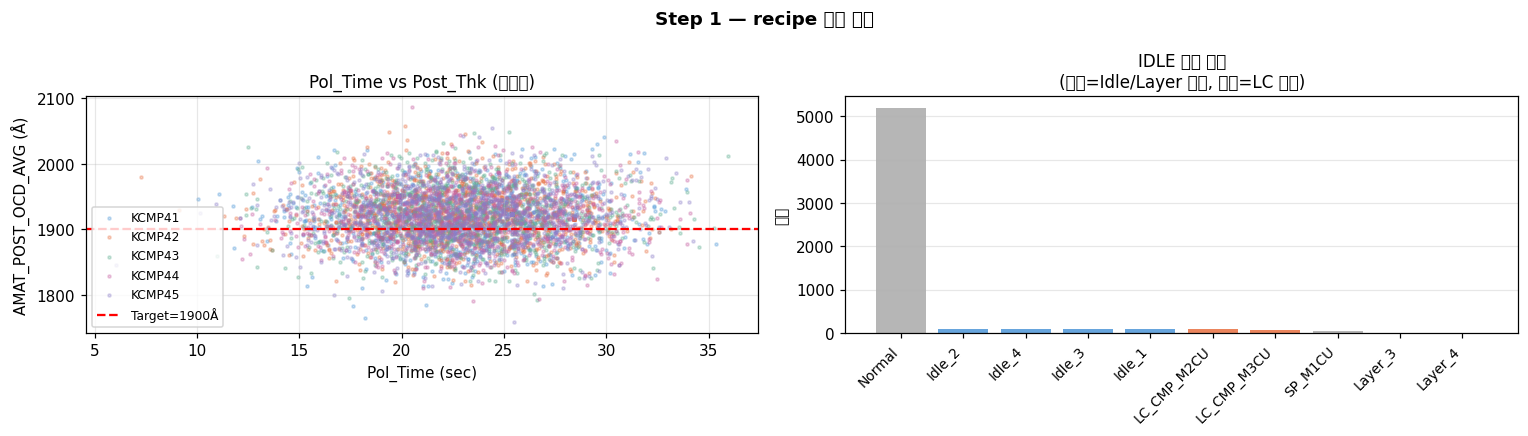

In [21]:
# ── compute_offset() Step 1: recipe 필터 + 전처리 ─────────────────────
temp_data = merge_df_off[
    (merge_df_off['operation_id'] == Oper_Code) &
    (merge_df_off['recipe_id']    == Recipe_ID)
].copy()

offset_columns = [col for col in temp_data.columns if 'OFFSET' in col]
temp_data.fillna(value={col: 0 for col in offset_columns}, inplace=True)

temp_data['eq_recipe'] = temp_data['eqp_id'] + '//' + temp_data['recipe_id']
temp_data.drop_duplicates(inplace=True)

temp_data['Pol_Time'] = temp_data[Pol_Para].sum(axis=1)
temp_data.dropna(subset=[Thk_Para], inplace=True)

b_cols = [col for col in temp_data.columns if '_B0' in col or '_B1' in col]
temp_data.fillna(temp_data.groupby(['eq_recipe'])[b_cols].transform('mean'), inplace=True)
temp_data[b_cols] = temp_data[b_cols].apply(pd.to_numeric, errors='coerce').fillna(temp_data[b_cols].mean())

print(f'필터 후 데이터: {len(temp_data)}행')
print(f'  operation_id = {Oper_Code}, recipe_id = {Recipe_ID}')
print(f'  Pol_Time 통계: mean={temp_data["Pol_Time"].mean():.2f}s  min={temp_data["Pol_Time"].min():.1f}s  max={temp_data["Pol_Time"].max():.1f}s')
print(f'  {Thk_Para} 통계: mean={temp_data[Thk_Para].mean():.1f}Å  std={temp_data[Thk_Para].std():.1f}Å')
print()
print(f'IDLE 분포:')
print(temp_data['IDLE'].value_counts().to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Step 1 — recipe 필터 결과', fontsize=12, fontweight='bold')

ax = axes[0]
for i, eqp in enumerate(sorted(temp_data['eqp_id'].unique())):
    sub = temp_data[temp_data['eqp_id'] == eqp]
    ax.scatter(sub['Pol_Time'], sub[Thk_Para],
               s=4, alpha=0.3, color=COLORS[i], label=eqp)
ax.axhline(Target, color='red', linewidth=1.5, linestyle='--', label=f'Target={Target:.0f}Å')
ax.set_xlabel('Pol_Time (sec)')
ax.set_ylabel(f'{Thk_Para} (Å)')
ax.set_title('Pol_Time vs Post_Thk (장비별)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
idle_counts = temp_data['IDLE'].replace('', 'Normal').value_counts()
colors_bar = ['#4C96D7' if 'Idle' in i or 'Layer' in i else
              '#E87040' if 'LC_' in i else '#AAA' for i in idle_counts.index]
ax.bar(range(len(idle_counts)), idle_counts.values, color=colors_bar, alpha=0.85)
ax.set_xticks(range(len(idle_counts)))
ax.set_xticklabels(idle_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('건수')
ax.set_title('IDLE 패턴 분포\n(파랑=Idle/Layer 대상, 주황=LC 패턴)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2 — 실측 RR vs 예측 RR_Pad 계산

```python
# 실측 연마율 (Actual Removal Rate)
RR = (Pre_Target - Post_Thk) / Pol_Time     # Å/sec

# 예측 연마율 (B1/B0 모델 기반)
RR_Pad = Pad_Para × B1 + B0                  # Å/sec
```

**해석:**
- `RR`이 `RR_Pad`보다 크면 → 실제로 더 많이 갈렸음 → 연마 시간을 줄여야 함 → OFFSET 음수
- `RR`이 `RR_Pad`보다 작으면 → 예측보다 덜 갈렸음 → 연마 시간을 늘려야 함 → OFFSET 양수

KCMP43 기준 통계:
  Pre_Target       : 2350 Å  (전공정 목표 두께)
  RR mean (Normal) : 19.6901 Å/sec
  RR mean (Idle)   : 19.0709 Å/sec
  RR_Pad mean      : 20.8419 Å/sec  (B1/B0 예측)

  → Normal vs Idle 구간 RR 차이: -0.6192 Å/sec


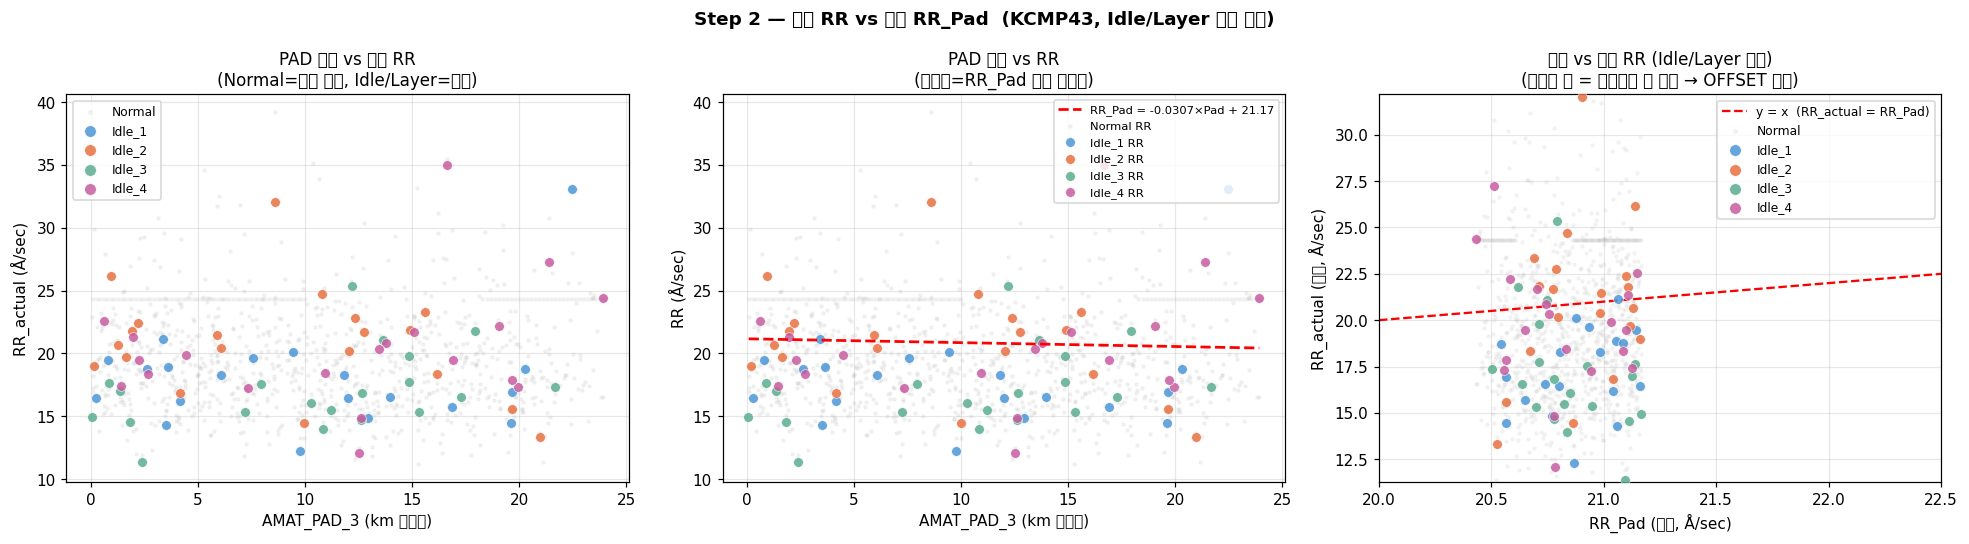

In [ ]:
# ── compute_offset() Step 2: RR 계산 ─────────────────────────────────

# 실측 RR = (Pre_Target - Post_Thk) / Pol_Time
temp_data['RR'] = (Pre_Target - temp_data[Thk_Para]) / temp_data['Pol_Time']

# 예측 RR = Pad_Para × B1 + B0
temp_data['RR_Pad'] = temp_data[Pad_Para] * temp_data[f'{APC_Para}_B1'] + temp_data[f'{APC_Para}_B0']

# IDLE 레이블 생성 + Idle_/Layer_ 필터
temp_data['IDLE_label'] = temp_data['IDLE'].replace('', 'Normal')
idle_mask  = temp_data['IDLE'].str.contains('Idle_|Layer_')
normal_mask = temp_data['IDLE_label'] == 'Normal'

temp_idle   = temp_data[idle_mask].copy()
temp_normal = temp_data[normal_mask].copy()

IDLE_COLORS = {
    'Idle_1' : '#4C96D7',
    'Idle_2' : '#E87040',
    'Idle_3' : '#5BAD8F',
    'Idle_4' : '#C65DA0',
    'Layer_1': '#8B7DC8',
    'Layer_2': '#D4A84B',
    'Layer_3': '#3ABFBF',
    'Layer_4': '#E05C5C',
}

demo_idle   = temp_idle[temp_idle['eqp_id'] == DEMO_EQP]
demo_normal = temp_normal[temp_normal['eqp_id'] == DEMO_EQP]

print(f'{DEMO_EQP} 기준 통계:')
print(f'  Pre_Target       : {Pre_Target:.0f} Å  (전공정 목표 두께)')
print(f'  RR mean (Normal) : {demo_normal["RR"].mean():.4f} Å/sec')
print(f'  RR mean (Idle)   : {demo_idle["RR"].mean():.4f} Å/sec')
print(f'  RR_Pad mean      : {demo_normal["RR_Pad"].mean():.4f} Å/sec  (B1/B0 예측)')
print()
print(f'  → Normal vs Idle 구간 RR 차이: {demo_idle["RR"].mean() - demo_normal["RR"].mean():+.4f} Å/sec')

# ── 시각화 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Step 2 — 실측 RR vs 예측 RR_Pad  ({DEMO_EQP}, Idle/Layer 구간 강조)',
             fontsize=12, fontweight='bold')

# ── 패널 1: PAD 마모 vs 실측 RR (Normal 회색 배경 + Idle/Layer 강조) ──
ax = axes[0]
ax.scatter(demo_normal[Pad_Para], demo_normal['RR'],
           s=4, alpha=0.15, color='#BBBBBB', label='Normal', zorder=1)
for label, color in IDLE_COLORS.items():
    sub = demo_idle[demo_idle['IDLE_label'] == label]
    if sub.empty:
        continue
    ax.scatter(sub[Pad_Para], sub['RR'],
               s=40, alpha=0.85, color=color, label=label,
               edgecolors='white', linewidths=0.4, zorder=3)
ax.set_xlabel(f'{Pad_Para} (km 마모량)')
ax.set_ylabel('RR_actual (Å/sec)')
ax.set_title('PAD 마모 vs 실측 RR\n(Normal=회색 배경, Idle/Layer=컬러)')
ax.legend(fontsize=8, markerscale=1.2)
ax.grid(alpha=0.3)

# ── 패널 2: PAD 마모 vs RR_Pad (회귀선) + Idle/Layer 포인트 ─────────
ax = axes[1]
# RR_Pad 회귀선 (Normal 데이터 기반)
pad_sorted = demo_normal[Pad_Para].sort_values()
b1_val = demo_normal[f'{APC_Para}_B1'].mean()
b0_val = demo_normal[f'{APC_Para}_B0'].mean()
ax.plot(pad_sorted, pad_sorted * b1_val + b0_val,
        color='red', linewidth=1.8, linestyle='--',
        label=f'RR_Pad = {b1_val:.4f}×Pad + {b0_val:.2f}', zorder=4)
ax.scatter(demo_normal[Pad_Para], demo_normal['RR'],
           s=4, alpha=0.15, color='#BBBBBB', label='Normal RR', zorder=1)
for label, color in IDLE_COLORS.items():
    sub = demo_idle[demo_idle['IDLE_label'] == label]
    if sub.empty:
        continue
    ax.scatter(sub[Pad_Para], sub['RR'],
               s=40, alpha=0.85, color=color, label=f'{label} RR',
               edgecolors='white', linewidths=0.4, zorder=3)
ax.set_xlabel(f'{Pad_Para} (km 마모량)')
ax.set_ylabel('RR (Å/sec)')
ax.set_title('PAD 마모 vs RR\n(빨간선=RR_Pad 예측 회귀선)')
ax.legend(fontsize=7.5)
ax.grid(alpha=0.3)

# ── 패널 3: RR_Pad vs RR_actual (Idle/Layer만) ────────────────────────
ax = axes[2]
# 대표 장비(KCMP43) 데이터 범위 기준으로 축 설정 (전체 idle 범위보다 좁고 명확)
rr_ref = pd.concat([demo_idle['RR'], demo_idle['RR_Pad'], demo_normal['RR'].dropna()])
lim_lo = rr_ref.quantile(0.01) - 1
lim_hi = rr_ref.quantile(0.99) + 1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
        'r--', linewidth=1.5, label='y = x  (RR_actual = RR_Pad)')
ax.scatter(demo_normal['RR_Pad'], demo_normal['RR'],
           s=4, alpha=0.12, color='#BBBBBB', label='Normal', zorder=1)
for label, color in IDLE_COLORS.items():
    sub = demo_idle[demo_idle['IDLE_label'] == label]
    if sub.empty:
        continue
    ax.scatter(sub['RR_Pad'], sub['RR'],
               s=40, alpha=0.85, color=color, label=label,
               edgecolors='white', linewidths=0.4, zorder=3)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel('RR_Pad (예측, Å/sec)')
ax.set_ylabel('RR_actual (실측, Å/sec)')
ax.set_title('예측 vs 실측 RR (Idle/Layer 구간)\n(대각선 위 = 예측보다 더 갈림 → OFFSET 음수)')
ax.legend(fontsize=8, markerscale=1.2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## IDLE 조건별 RR 분포 비교

Idle_/Layer_ 조건에서의 RR이 Normal 운전과 **다른 분포**를 가지는지 확인한다.  
이 차이가 IDLE별로 서로 다른 OFFSET 값을 만드는 근거가 된다.

- **Normal**: 일반 공정 운전 (Idle/LC 없음)
- **Idle_N**: 장비가 일시 정지 후 재가동되는 구간 — 패드 온도·수분 상태가 달라 RR이 변할 수 있음
- **Layer_N**: 층별 구분 공정 구간

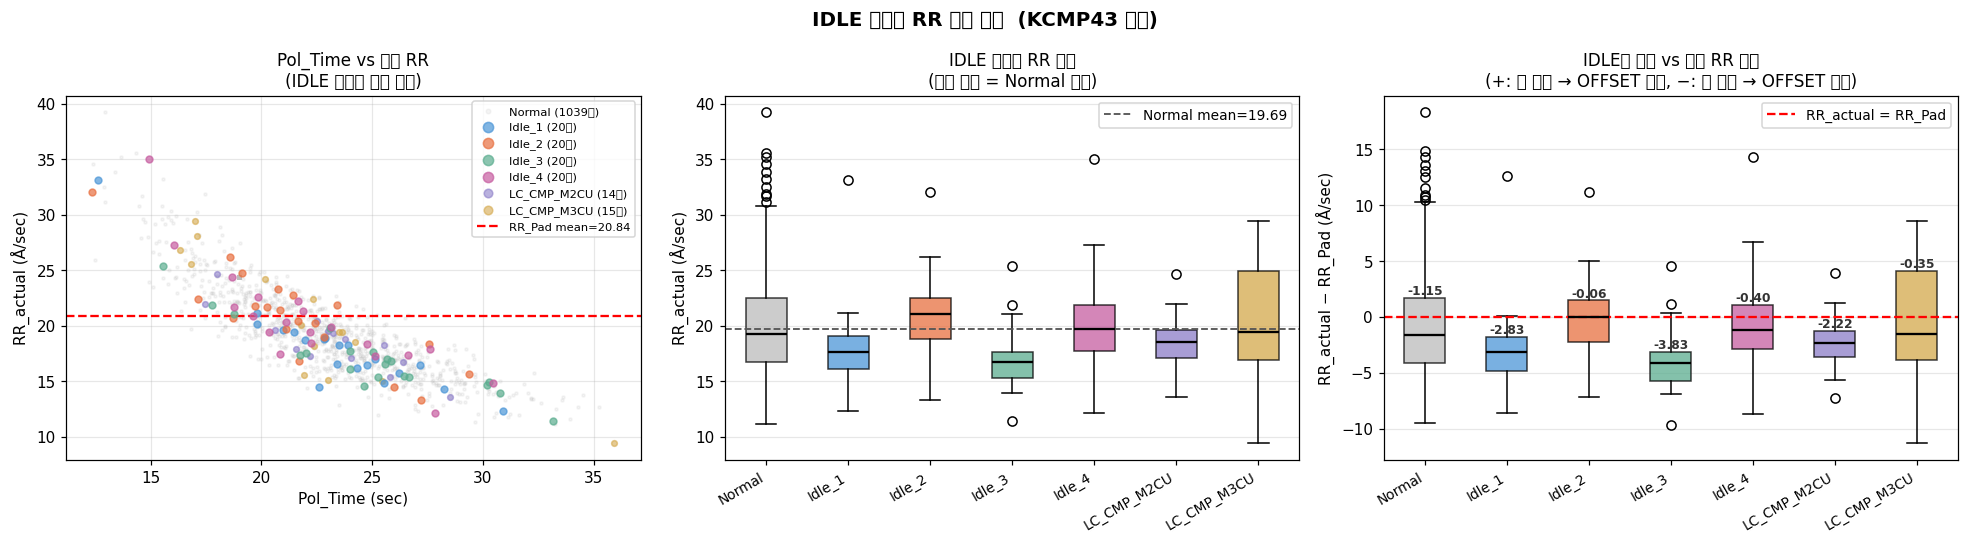

KCMP43 IDLE별 RR 통계 요약

             count    mean    std  RR_diff_mean
IDLE_label                                     
Idle_1          20  18.032  4.195        -2.828
Idle_2          20  20.832  4.211        -0.062
Idle_3          20  17.020  3.107        -3.830
Idle_4          20  20.400  4.764        -0.405
LC_CMP_M2CU     14  18.591  2.741        -2.224
LC_CMP_M3CU     15  20.474  5.593        -0.352
Normal        1039  19.690  3.961        -1.152
SP_M1CU          9  21.955  8.716         0.973

In [8]:
# ── IDLE 조건별 RR 분포 비교 시각화 ─────────────────────────────────
import matplotlib.patches as mpatches

# IDLE 레이블 그룹화
temp_data['IDLE_label'] = temp_data['IDLE'].replace('', 'Normal')

# 시각화 대상 IDLE 그룹 정의
idle_groups = {
    'Normal'     : {'color': '#BBBBBB', 'alpha': 0.15, 'zorder': 1, 's': 4},
    'Idle_1'     : {'color': '#4C96D7', 'alpha': 0.70, 'zorder': 3, 's': 20},
    'Idle_2'     : {'color': '#E87040', 'alpha': 0.70, 'zorder': 3, 's': 20},
    'Idle_3'     : {'color': '#5BAD8F', 'alpha': 0.70, 'zorder': 3, 's': 20},
    'Idle_4'     : {'color': '#C65DA0', 'alpha': 0.70, 'zorder': 3, 's': 20},
    'LC_CMP_M2CU': {'color': '#8B7DC8', 'alpha': 0.60, 'zorder': 2, 's': 14},
    'LC_CMP_M3CU': {'color': '#D4A84B', 'alpha': 0.60, 'zorder': 2, 's': 14},
}

# ── 장비 선택 (대표 장비 + 전체 비교) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'IDLE 조건별 RR 분포 비교  ({DEMO_EQP} 기준)', fontsize=13, fontweight='bold')

demo = temp_data[temp_data['eqp_id'] == DEMO_EQP].copy()

# ── 패널 1: Pol_Time vs RR (scatter, IDLE 색상 구분) ─────────────────
ax = axes[0]
for label, style in idle_groups.items():
    sub = demo[demo['IDLE_label'] == label]
    if sub.empty:
        continue
    ax.scatter(sub['Pol_Time'], sub['RR'],
               c=style['color'], s=style['s'],
               alpha=style['alpha'], zorder=style['zorder'],
               label=f'{label} ({len(sub)}건)')

# RR_Pad 평균선
rr_pad_mean = demo['RR_Pad'].mean()
ax.axhline(rr_pad_mean, color='red', linewidth=1.5, linestyle='--',
           label=f'RR_Pad mean={rr_pad_mean:.2f}')
ax.set_xlabel('Pol_Time (sec)')
ax.set_ylabel('RR_actual (Å/sec)')
ax.set_title('Pol_Time vs 실측 RR\n(IDLE 조건별 색상 구분)')
ax.legend(fontsize=7.5, markerscale=1.5)
ax.grid(alpha=0.3)

# ── 패널 2: RR 분포 Box plot (IDLE 조건별) ───────────────────────────
ax = axes[1]
box_labels = [g for g in idle_groups if g in demo['IDLE_label'].values]
box_data   = [demo[demo['IDLE_label'] == g]['RR'].values for g in box_labels]
bp = ax.boxplot(box_data, patch_artist=True, medianprops={'color':'black','linewidth':1.5},
                whiskerprops={'linewidth':1}, capprops={'linewidth':1})
for patch, label in zip(bp['boxes'], box_labels):
    patch.set_facecolor(idle_groups[label]['color'])
    patch.set_alpha(0.75)

# Normal 평균 기준선
normal_mean = demo[demo['IDLE_label'] == 'Normal']['RR'].mean()
ax.axhline(normal_mean, color='#555', linewidth=1.2, linestyle='--',
           label=f'Normal mean={normal_mean:.2f}')
ax.set_xticks(range(1, len(box_labels)+1))
ax.set_xticklabels(box_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RR_actual (Å/sec)')
ax.set_title('IDLE 조건별 RR 분포\n(회색 점선 = Normal 평균)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── 패널 3: RR_actual - RR_Pad (잔차) by IDLE ────────────────────────
ax = axes[2]
demo['RR_diff'] = demo['RR'] - demo['RR_Pad']

diff_data   = [demo[demo['IDLE_label'] == g]['RR_diff'].values for g in box_labels]
bp2 = ax.boxplot(diff_data, patch_artist=True,
                 medianprops={'color':'black','linewidth':1.5},
                 whiskerprops={'linewidth':1}, capprops={'linewidth':1})
for patch, label in zip(bp2['boxes'], box_labels):
    patch.set_facecolor(idle_groups[label]['color'])
    patch.set_alpha(0.75)

ax.axhline(0, color='red', linewidth=1.5, linestyle='--', label='RR_actual = RR_Pad')

# 각 박스 위에 평균값 표시
for j, g in enumerate(box_labels):
    vals = demo[demo['IDLE_label'] == g]['RR_diff'].dropna()
    if len(vals) > 0:
        m = vals.mean()
        ax.text(j+1, vals.quantile(0.75)+0.3, f'{m:+.2f}',
                ha='center', fontsize=8, color='#333',
                fontweight='bold')

ax.set_xticks(range(1, len(box_labels)+1))
ax.set_xticklabels(box_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RR_actual − RR_Pad (Å/sec)')
ax.set_title('IDLE별 실측 vs 예측 RR 잔차\n(+: 덜 갈림 → OFFSET 양수, −: 더 갈림 → OFFSET 음수)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── 수치 요약 ────────────────────────────────────────────────────────
print(f'{DEMO_EQP} IDLE별 RR 통계 요약')
summary = demo.groupby('IDLE_label')['RR'].agg(['count','mean','std']).round(3)
summary['RR_diff_mean'] = demo.groupby('IDLE_label')['RR_diff'].mean().round(3)
print(summary.to_string())


## Step 3 — OFFSET 계산 & clip

```python
delta = Pre_Target - Target   # 목표 연마량 (Å)

OFFSET = delta / RR_actual - delta / RR_Pad    # 초 단위 연마시간 보정량
OFFSET = OFFSET.clip(-5, 3)                    # 이상치 제한

# LC Truing 구간은 OFFSET=0 처리 (패드 컨디셔닝 구간 제외)
temp_data.loc[IDLE.str.contains('LC_T_|LC_TB_'), 'OFFSET'] = 0
```

**OFFSET 의미:**  
- **음수**: 실제 RR > 예측 RR → 예측보다 더 많이 갈림 → APC가 연마시간을 줄여야 함  
- **양수**: 실제 RR < 예측 RR → 예측보다 덜 갈림 → APC가 연마시간을 늘려야 함

KCMP43 OFFSET 통계 (전체, clip 전):

  delta         : 450 Å

  OFFSET_raw    : mean=1.1414  std=4.8274

  OFFSET (clip) : mean=0.1571  min=-5.00  max=3.00

  clip된 건수   : 2416 / 5817

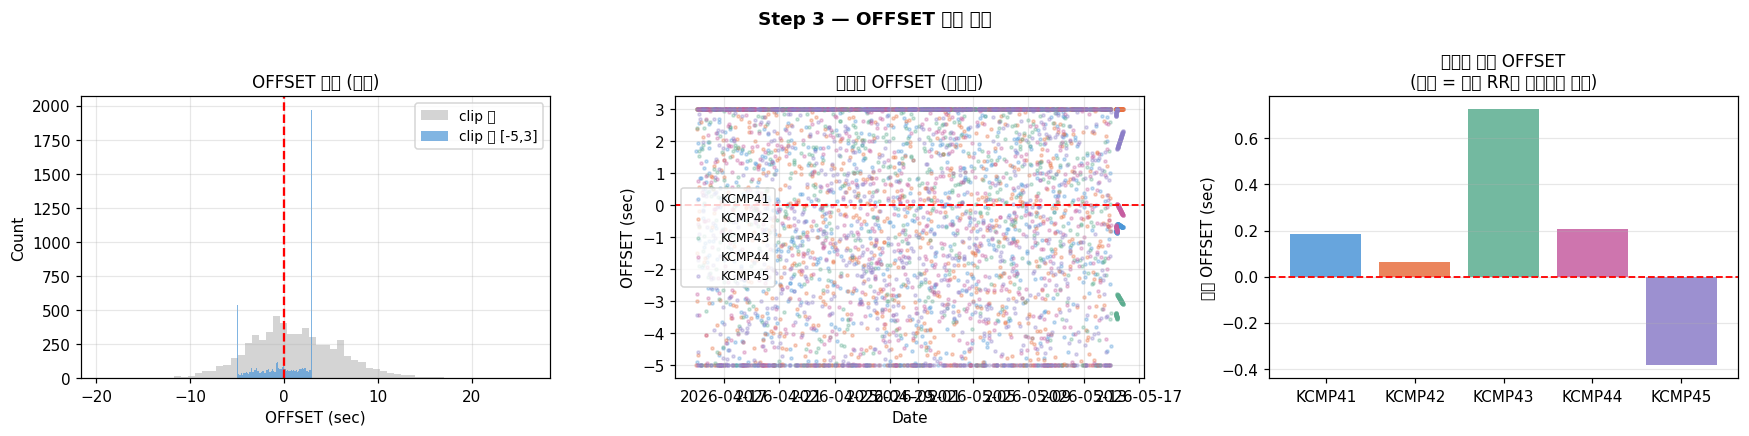

In [9]:
# ── compute_offset() Step 3: OFFSET 계산 ─────────────────────────────
delta = Pre_Target - Target   # 450 Å
temp_data['OFFSET_raw'] = delta / temp_data['RR'] - delta / temp_data['RR_Pad']
temp_data['OFFSET']     = temp_data['OFFSET_raw'].clip(-5, 3)

# LC_T_ / LC_TB_ 구간은 OFFSET=0 (이 샘플에는 없지만 실제 데이터에서 적용)
temp_data.loc[temp_data['IDLE'].str.contains('LC_T_|LC_TB_'), 'OFFSET'] = 0

# recipe_group, APC_Para 컬럼 추가 (compute_lc_offset에서 필요)
temp_data['recipe_group'] = temp_data['recipe_id'].apply(lambda x: '_'.join(x.split('_')[:3]))
temp_data['APC_Para']     = APC_Para

demo = temp_data[temp_data['eqp_id'] == DEMO_EQP]
print(f'{DEMO_EQP} OFFSET 통계 (전체, clip 전):')
print(f'  delta         : {delta:.0f} Å')
print(f'  OFFSET_raw    : mean={temp_data["OFFSET_raw"].dropna().mean():.4f}  std={temp_data["OFFSET_raw"].dropna().std():.4f}')
print(f'  OFFSET (clip) : mean={temp_data["OFFSET"].dropna().mean():.4f}  min={temp_data["OFFSET"].dropna().min():.2f}  max={temp_data["OFFSET"].dropna().max():.2f}')
print(f'  clip된 건수   : {(temp_data["OFFSET_raw"] != temp_data["OFFSET"]).sum()} / {len(temp_data)}')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Step 3 — OFFSET 계산 결과', fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(temp_data['OFFSET_raw'].dropna(), bins=60, color='#aaa', alpha=0.5, label='clip 전')
ax.hist(temp_data['OFFSET'].dropna(), bins=60, color='#4C96D7', alpha=0.7, label='clip 후 [-5,3]')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('OFFSET (sec)')
ax.set_ylabel('Count')
ax.set_title('OFFSET 분포 (전체)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for i, eqp in enumerate(sorted(temp_data['eqp_id'].unique())):
    sub = temp_data[temp_data['eqp_id'] == eqp]
    ax.scatter(sub['Date'], sub['OFFSET'], s=4, alpha=0.3, color=COLORS[i], label=eqp)
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('OFFSET (sec)')
ax.set_title('시계열 OFFSET (장비별)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
eqp_list = sorted(temp_data['eqp_id'].unique())
means = [temp_data[temp_data['eqp_id']==e]['OFFSET'].mean() for e in eqp_list]
ax.bar(eqp_list, means, color=COLORS[:len(eqp_list)], alpha=0.85)
ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
ax.set_ylabel('평균 OFFSET (sec)')
ax.set_title('장비별 평균 OFFSET\n(음수 = 실제 RR이 예측보다 높음)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4 — Idle_/Layer_ 필터 + 5건 기준 그룹 평균

```python
# Idle_ 또는 Layer_ 패턴만 추출
temp_data_idle = temp_data[
    temp_data['IDLE'].str.contains('Idle_') | temp_data['IDLE'].str.contains('Layer_')
]

# 장비/레시피/IDLE 조합별 5건 이상인 그룹만 유효
grouped         = temp_data_idle.groupby(['eqp_id','recipe_id','IDLE']).size()
filtered_groups = grouped[grouped >= 5]

# 그룹 평균 → 저장
idle_table = filtered_data.groupby(['eqp_id','recipe_id','IDLE'])['OFFSET'].mean()
```

**Idle_N**: 연마 도중 일시 정지(Idle) 상태, **Layer_N**: 층별 구분 공정 구간

Idle_/Layer_ 전체: 404행

5건 이상 그룹 수 : 20

최종 idle_table  : 20건

── idle_table (MongoDB 저장 대상) ──────────────────────────────

,eqp_id,recipe_id,IDLE,OFFSET,APC_Para
0,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_1,0.840056,P3
1,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_2,-0.304271,P3
2,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_3,0.897094,P3
3,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_4,-0.322323,P3
4,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_1,-0.649794,P3
5,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_2,-0.632526,P3
6,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_3,0.253540,P3
7,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_4,-1.259191,P3
8,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_1,2.107231,P3
9,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_2,-0.035000,P3


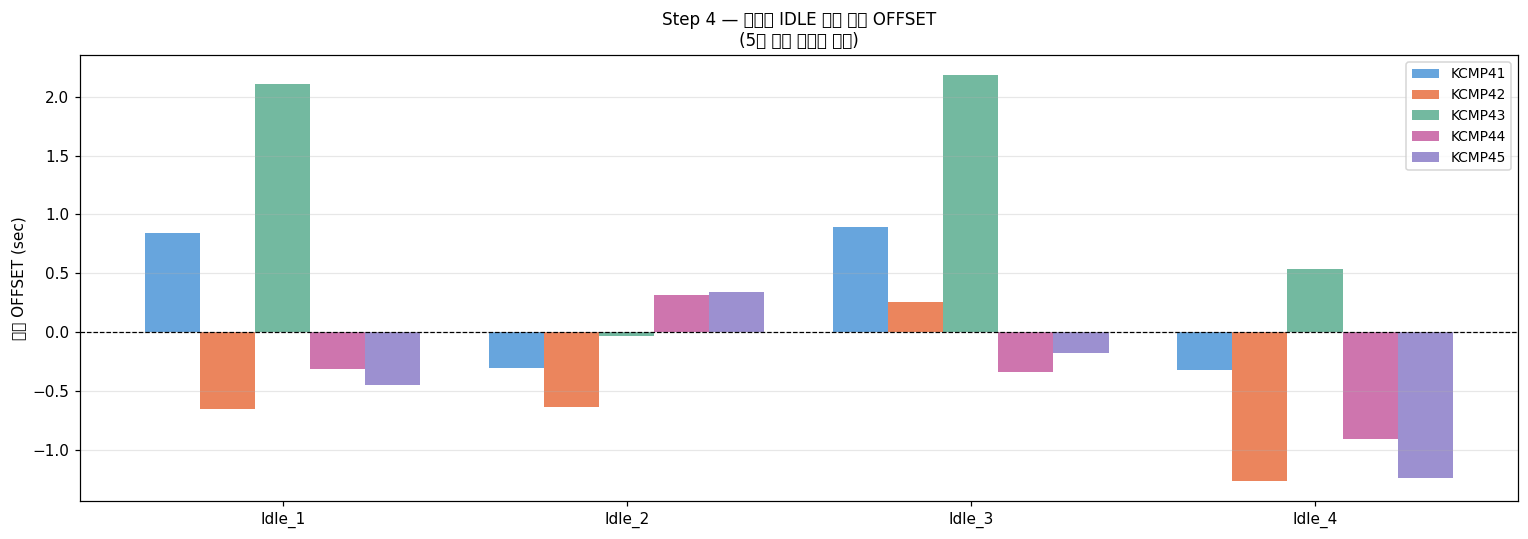

In [10]:
# ── compute_offset() Step 4: Idle_/Layer_ 필터 + 5건 기준 ─────────────
temp_data_idle = temp_data[
    temp_data['IDLE'].str.contains('Idle_') | temp_data['IDLE'].str.contains('Layer_')
].copy()

grouped         = temp_data_idle.groupby(['eqp_id','recipe_id','IDLE']).size().reset_index(name='count')
filtered_groups = grouped[grouped['count'] >= 5]
filtered_data   = temp_data_idle.merge(filtered_groups[['eqp_id','recipe_id','IDLE']],
                                        on=['eqp_id','recipe_id','IDLE'])
idle_table      = filtered_data.groupby(['eqp_id','recipe_id','IDLE'])['OFFSET'].mean().reset_index()
idle_table['IDLE']     = idle_table['IDLE'].replace('','Normal')
idle_table['APC_Para'] = APC_Para
idle_table['Date']     = pd.Timestamp.now()

print(f'Idle_/Layer_ 전체: {len(temp_data_idle)}행')
print(f'5건 이상 그룹 수 : {len(filtered_groups)}')
print(f'최종 idle_table  : {len(idle_table)}건')
print()
print('── idle_table (MongoDB 저장 대상) ──────────────────────────────')
display(idle_table.drop(columns=['Date']))

# 시각화
fig, ax = plt.subplots(figsize=(14, 5))
idle_types = sorted(idle_table['IDLE'].unique())
x = np.arange(len(idle_types))
width = 0.16
eqp_list = sorted(idle_table['eqp_id'].unique())
for i, eqp in enumerate(eqp_list):
    sub = idle_table[idle_table['eqp_id'] == eqp]
    vals = [sub[sub['IDLE']==t]['OFFSET'].values[0]
            if t in sub['IDLE'].values else np.nan for t in idle_types]
    offset_x = (i - len(eqp_list)/2 + 0.5) * width
    ax.bar(x + offset_x, vals, width, label=eqp, color=COLORS[i], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(idle_types)
ax.set_ylabel('평균 OFFSET (sec)')
ax.set_title('Step 4 — 장비별 IDLE 구간 평균 OFFSET\n(5건 이상 그룹만 포함)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5 — `compute_offset()` 전체 실행 (함수 직접 호출)

위 Step 1~4를 하나로 묶은 `OFFSET_Get.compute_offset()`을 직접 호출한다.  
`push_df()` 결과는 `_STORE`에 캡처된다.

In [11]:
# ── _STORE 초기화 후 compute_offset() 직접 호출 ───────────────────────
for k in [k for k in _STORE if 'OFFSET' in k]:
    _STORE[k] = []

print('── OFFSET_Get.compute_offset() 실행 ──────────────────────────────')
result_df = OFFSET_Get.compute_offset(merge_df_off.copy(), key, pol_type=3, Fab=Fab)

# 저장된 idle_table 확인
idle_store = pd.DataFrame([row for v in _STORE.values() for row in v])
print(f'\nidle_table (MongoDB 저장): {len(idle_store)}건')
print(f'IDLE 패턴: {sorted(idle_store["IDLE"].unique())}')

print()
print('── 저장된 idle_table ────────────────────────────────────────────')
display(idle_store.drop(columns=['Date']))

── OFFSET_Get.compute_offset() 실행 ──────────────────────────────

    [MongoDB mock] push_df  → MICO_OFFSET_LC_M1 CU CMP_M10: 20건 저장


idle_table (MongoDB 저장): 20건

IDLE 패턴: ['Idle_1', 'Idle_2', 'Idle_3', 'Idle_4']

── 저장된 idle_table ────────────────────────────────────────────

,eqp_id,recipe_id,IDLE,OFFSET,APC_Para
0,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_1,0.840056,P3
1,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_2,-0.304271,P3
2,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_3,0.897094,P3
3,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_4,-0.322323,P3
4,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_1,-0.649794,P3
5,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_2,-0.632526,P3
6,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_3,0.253540,P3
7,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_4,-1.259191,P3
8,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_1,2.107231,P3
9,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_2,-0.035000,P3


## Step 6 — `compute_lc_offset()` : LC 패턴 처리

패드 교체(LC_) 직후의 IDLE 구간을 별도로 집계한다.

```python
# LC_ 패턴: LC_CMP_M2CU, LC_CMP_M3CU 등
temp_data_lc = temp_data[IDLE.str.contains('LC_') & ~ADD/T/TB 제외]

# ADD_/T_/TB_ 패턴: 별도 Truing 구간
temp_data_tb = temp_data[IDLE.str.contains('_ADD_|_T_|_TB_')]

# Offset_Group='Y': 장비번호 제거 → LC_M2CU, LC_M3CU 로 단순화
# LC_CMP_M2CU → parts[0] + '_' + parts[2]  = 'LC_M2CU'
if Offset_Group == 'Y':
    temp_data_lc['IDLE'] = IDLE.apply(lambda x: x.split('_')[0]+'_'+x.split('_')[2])

# _build_idle_table(): recipe_group 단위 평균화
# eq_recipe_apc 기준 집계 → recipe_group(레시피 앞 3파트) 평균 적용
```

In [12]:
# ── compute_lc_offset() 내부 단계별 시연 ─────────────────────────────

# result_df: compute_offset()이 반환한 전체 데이터 (LC 포함)
result_df['eq_recipe_apc'] = result_df['eq_recipe'] + '//' + result_df['APC_Para']
result_df['IDLE'] = result_df['IDLE'].fillna('Normal')

# ① LC_ 패턴 분리
lc_mask = (
    result_df['IDLE'].str.contains('LC_') &
    ~result_df['IDLE'].str.contains('_ADD_') &
    ~result_df['IDLE'].str.contains('_T_') &
    ~result_df['IDLE'].str.contains('_TB_')
)
tb_mask = (
    result_df['IDLE'].str.contains('_ADD_') |
    result_df['IDLE'].str.contains('_T_') |
    result_df['IDLE'].str.contains('_TB_')
)

temp_data_lc = result_df[lc_mask].copy()
temp_data_tb = result_df[tb_mask].copy()

print('── LC 패턴 분류 ─────────────────────────────────────────────────')
print(f'  LC_ 패턴  : {len(temp_data_lc)}건  {sorted(temp_data_lc["IDLE"].unique())}')
print(f'  ADD/T/TB  : {len(temp_data_tb)}건  (이 샘플 데이터에는 없음)')

# ② Offset_Group='Y': IDLE 레이블 단순화
print(f'\n── Offset_Group="{Offset_Group}" → IDLE 레이블 변환 ──────────────────')
original_idle = temp_data_lc['IDLE'].unique()
if Offset_Group == 'Y':
    temp_data_lc['IDLE'] = temp_data_lc['IDLE'].apply(
        lambda x: '_'.join([x.split('_')[0], x.split('_')[2]])
    )
for orig in original_idle:
    new = '_'.join([orig.split('_')[0], orig.split('_')[2]])
    print(f'  {orig:20s} → {new}')

print('\n  → 장비번호(KCMP41/42...) 제거 후 recipe_group 단위로 평균화 가능해짐')

# ③ combined + _build_idle_table()
combined = pd.concat([temp_data_lc, temp_data_tb], axis=0)
print(f'\ncombined: {len(combined)}건')

lc_offset = OFFSET_Get._build_idle_table(combined)
print(f'_build_idle_table() 결과: {len(lc_offset)}건')
print()
print('── _build_idle_table() 내부 recipe_group 평균화 과정 ────────────')
print('  1. eq_recipe_apc/IDLE 기준 OFFSET 평균 집계')
print('  2. 전체 eq_recipe_apc × IDLE 조합 생성 (누락 조합 포함)')
print('  3. recipe_group(레시피 앞 3파트) 별 평균으로 보완')
print()
display(lc_offset[['eqp_id','recipe_id','IDLE','OFFSET_Origin','OFFSET']].sort_values(['eqp_id','IDLE']))

── LC 패턴 분류 ─────────────────────────────────────────────────

  LC_ 패턴  : 168건  ['LC_CMP_M2CU', 'LC_CMP_M3CU']

  ADD/T/TB  : 0건  (이 샘플 데이터에는 없음)


── Offset_Group="Y" → IDLE 레이블 변환 ──────────────────

  LC_CMP_M2CU          → LC_M2CU

...

── _build_idle_table() 내부 recipe_group 평균화 과정 ────────────

  1. eq_recipe_apc/IDLE 기준 OFFSET 평균 집계

  2. 전체 eq_recipe_apc × IDLE 조합 생성 (누락 조합 포함)

  3. recipe_group(레시피 앞 3파트) 별 평균으로 보완

,eqp_id,recipe_id,IDLE,OFFSET_Origin,OFFSET
0,KCMP41,E2_M1CU_R12_TSV.CAS,LC_M2CU,0.350232,0.289977
1,KCMP41,E2_M1CU_R12_TSV.CAS,LC_M3CU,-1.073009,-0.352146
2,KCMP42,E2_M1CU_R12_TSV.CAS,LC_M2CU,0.264333,0.289977
3,KCMP42,E2_M1CU_R12_TSV.CAS,LC_M3CU,-0.817302,-0.352146
4,KCMP43,E2_M1CU_R12_TSV.CAS,LC_M2CU,1.719684,0.289977
5,KCMP43,E2_M1CU_R12_TSV.CAS,LC_M3CU,-0.073028,-0.352146
6,KCMP44,E2_M1CU_R12_TSV.CAS,LC_M2CU,-0.374204,0.289977
7,KCMP44,E2_M1CU_R12_TSV.CAS,LC_M3CU,0.674006,-0.352146
8,KCMP45,E2_M1CU_R12_TSV.CAS,LC_M2CU,-0.510158,0.289977
9,KCMP45,E2_M1CU_R12_TSV.CAS,LC_M3CU,-0.471398,-0.352146


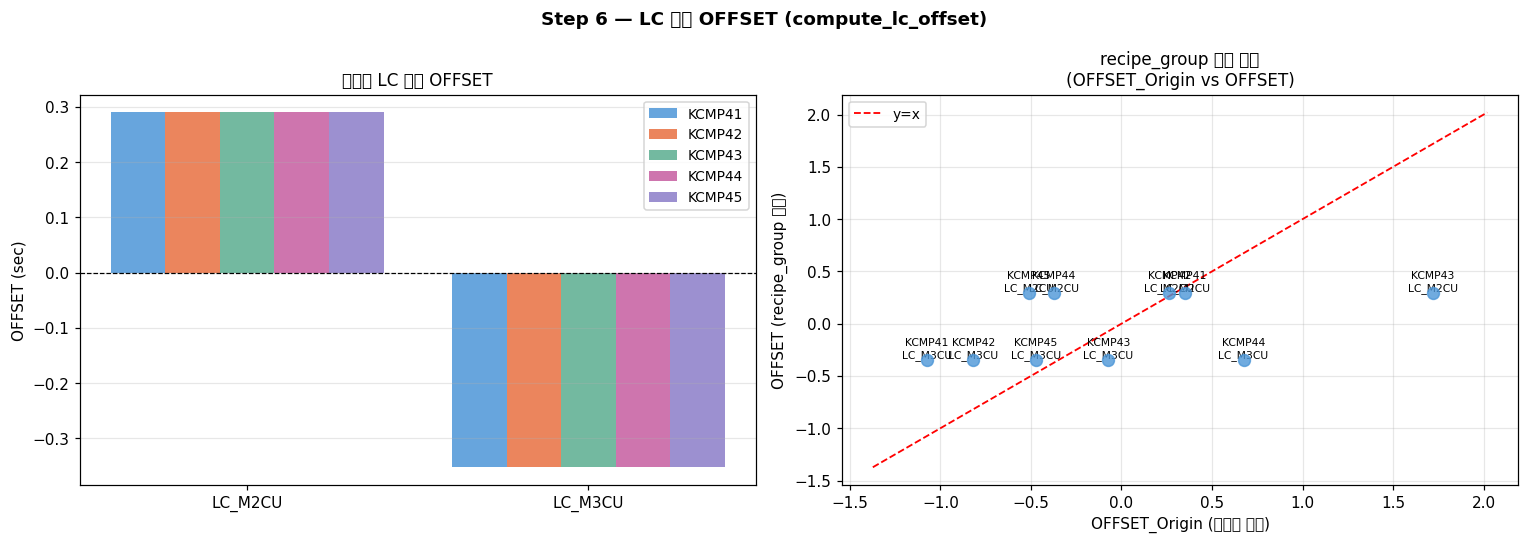

In [13]:
# ── LC OFFSET 시각화 ─────────────────────────────────────────────────
lc_final = lc_offset.copy()
lc_final['OFFSET'] = lc_final['OFFSET'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 6 — LC 패턴 OFFSET (compute_lc_offset)', fontsize=12, fontweight='bold')

# 장비별 LC OFFSET
ax = axes[0]
lc_types  = sorted(lc_final['IDLE'].unique())
eqp_list  = sorted(lc_final['eqp_id'].unique())
x         = np.arange(len(lc_types))
width     = 0.16
for i, eqp in enumerate(eqp_list):
    sub  = lc_final[lc_final['eqp_id'] == eqp]
    vals = [sub[sub['IDLE']==t]['OFFSET'].values[0] if t in sub['IDLE'].values else 0
            for t in lc_types]
    offset_x = (i - len(eqp_list)/2 + 0.5) * width
    ax.bar(x + offset_x, vals, width, label=eqp, color=COLORS[i], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(lc_types)
ax.set_ylabel('OFFSET (sec)')
ax.set_title('장비별 LC 패턴 OFFSET')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# OFFSET_Origin vs OFFSET (recipe_group 보완 효과)
ax = axes[1]
valid = lc_final.dropna(subset=['OFFSET_Origin','OFFSET'])
ax.scatter(valid['OFFSET_Origin'], valid['OFFSET'],
           s=60, alpha=0.8, color='#4C96D7', zorder=5)
for _, row in valid.iterrows():
    ax.annotate(f"{row['eqp_id']}\n{row['IDLE']}",
                (row['OFFSET_Origin'], row['OFFSET']),
                fontsize=7, ha='center', va='bottom')
lim_all = lc_final[['OFFSET_Origin','OFFSET']].values.flatten()
lim_all = lim_all[~np.isnan(lim_all)]
lo, hi  = lim_all.min()-0.3, lim_all.max()+0.3
ax.plot([lo,hi],[lo,hi],'r--',linewidth=1.2, label='y=x')
ax.set_xlabel('OFFSET_Origin (장비별 원본)')
ax.set_ylabel('OFFSET (recipe_group 평균)')
ax.set_title('recipe_group 보완 효과\n(OFFSET_Origin vs OFFSET)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 최종 정리 — `Module_Get.compute_offset()` 전체 실행

`Module_Get.compute_offset()`은 위 모든 단계를 자동으로 순차 실행한다:

```
load_rr_data()          ← B1/B0 로드 → merge_df에 결합
compute_offset() × N    ← FB_Type=TIME 행마다 OFFSET 산출 + 저장
compute_lc_offset()     ← LC 패턴 집계 + 저장
```

In [14]:
from Common.Module import Module_Get
import Common.OFFSET as _offset_mod

# ── load_rr_data Mock: 가상 B1/B0 주입 ───────────────────────────────
# 실서버에서는 MongoDB RR 컬렉션에서 읽음
def _mock_load_rr(mdf, Fab, LC, OD, apc_list, mu, mdb):
    out = mdf.copy()
    for p in apc_list:
        out[f'{p}_B1'] = 0.80
        out[f'{p}_B0'] = 5.00
    print(f'    [mock] load_rr_data: B1=0.80 / B0=5.00 삽입 for {list(apc_list)}')
    return out
_offset_mod.OFFSET_Get.load_rr_data = staticmethod(_mock_load_rr)

# ── _STORE 초기화 ─────────────────────────────────────────────────────
for k in [k for k in _STORE if 'OFFSET' in k]:
    _STORE[k] = []

mico_key = mico.copy()
mico_key['Group_Name'] = mico_key['Group_Name'].fillna('not_group')

print('── Module_Get.compute_offset() 전체 실행 ────────────────────────')
Module_Get.compute_offset(merge_df.copy(), mico_key, pol_type=3)

# ── 결과 수집 ─────────────────────────────────────────────────────────
all_rows = [row for v in _STORE.values() for row in v]
offset_result = pd.DataFrame(all_rows)
offset_result['OFFSET'] = pd.to_numeric(offset_result['OFFSET'], errors='coerce')

print(f'\n최종 결과: {len(offset_result)}건')
print(f'IDLE 패턴: {sorted(offset_result["IDLE"].unique())}')
print()
display(offset_result[['eqp_id','recipe_id','IDLE','OFFSET','APC_Para']].sort_values(['IDLE','eqp_id']))

── Module_Get.compute_offset() 전체 실행 ────────────────────────


  [Offset] M10 | LC | M1 CU CMP 시작

    APC_Para 목록: ['P3'] | Offset_Group=Y

    [mock] load_rr_data: B1=0.80 / B0=5.00 삽입 for ['P3']

    [MongoDB mock] push_df  → MICO_OFFSET_LC_M1 CU CMP_M10: 20건 저장

    [MongoDB mock] push_df  → MICO_OFFSET_LC_M1 CU CMP_M10: 10건 저장

  [Offset] M10 | LC | M1 CU CMP 완료


최종 결과: 30건

IDLE 패턴: ['Idle_1', 'Idle_2', 'Idle_3', 'Idle_4', 'LC_M2CU', 'LC_M3CU']

,eqp_id,recipe_id,IDLE,OFFSET,APC_Para
0,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_1,-4.144893,P3
4,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_1,-3.714363,P3
8,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_1,-2.489083,P3
12,KCMP44,E2_M1CU_R12_TSV.CAS,Idle_1,-3.266844,P3
16,KCMP45,E2_M1CU_R12_TSV.CAS,Idle_1,-2.284107,P3
1,KCMP41,E2_M1CU_R12_TSV.CAS,Idle_2,-4.623845,P3
5,KCMP42,E2_M1CU_R12_TSV.CAS,Idle_2,-4.320538,P3
9,KCMP43,E2_M1CU_R12_TSV.CAS,Idle_2,-3.903589,P3
13,KCMP44,E2_M1CU_R12_TSV.CAS,Idle_2,-3.111763,P3
17,KCMP45,E2_M1CU_R12_TSV.CAS,Idle_2,-1.906016,P3


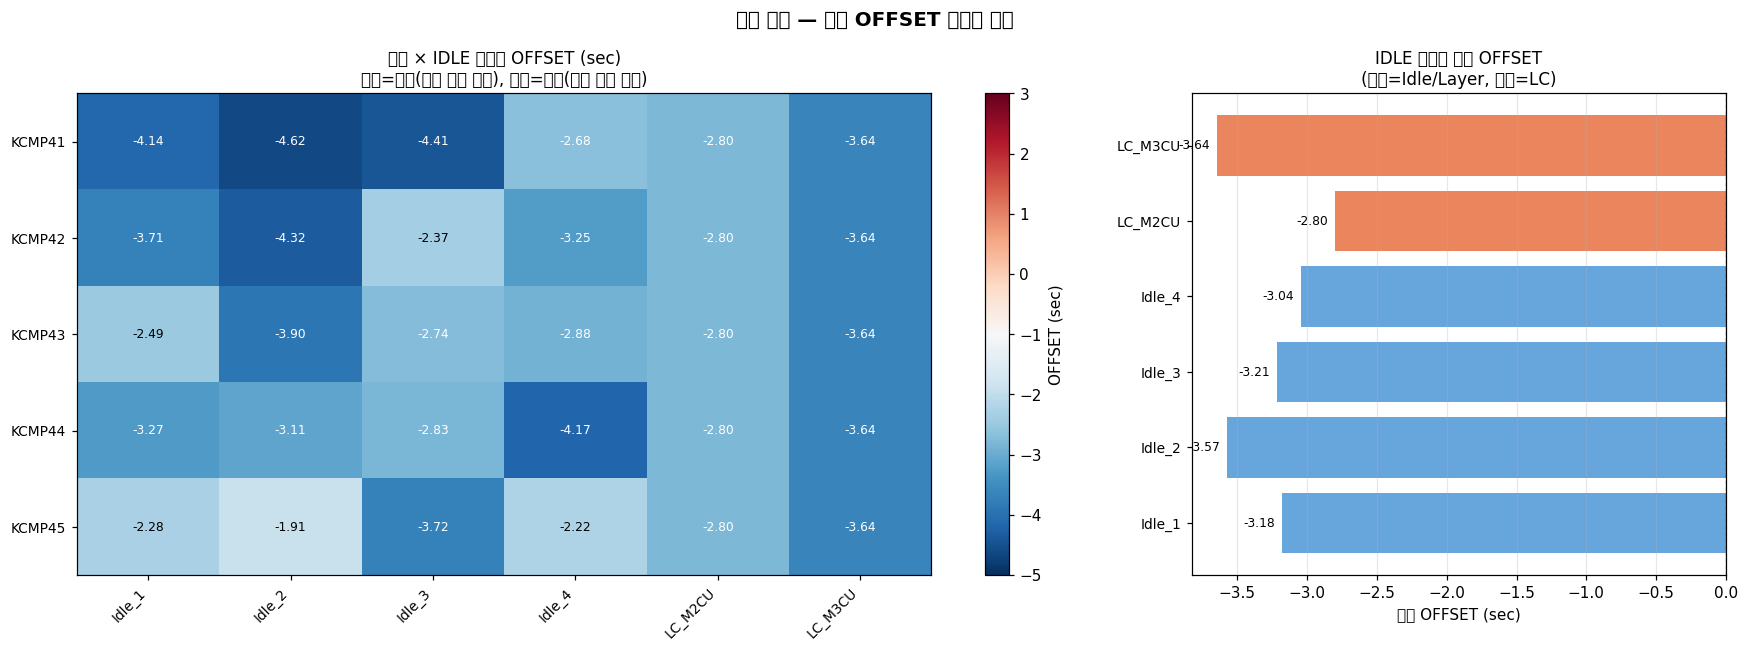


── OFFSET 알고리즘 요약 ──────────────────────────────────────────

  ① load_rr_data()      : B1/B0 계수 로드 → merge_df 결합

  ② RR_actual           : (Pre_Target - Post_Thk) / Pol_Time

  ③ RR_Pad              : Pad_Para × B1 + B0

  ④ OFFSET              : delta/RR - delta/RR_Pad  (clip[-5, 3])

  ⑤ Idle/Layer 저장      : 20건 → MongoDB

  ⑥ LC 패턴 저장         : 10건 → MongoDB (recipe_group 평균)

In [15]:
# ── 최종 OFFSET 요약 시각화 ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1])
fig.suptitle('최종 결과 — 전체 OFFSET 학습값 요약', fontsize=13, fontweight='bold')

# 왼쪽: 전체 OFFSET 히트맵 (장비 × IDLE)
ax1 = fig.add_subplot(gs[0])
eqp_order  = sorted(offset_result['eqp_id'].unique())
idle_order = sorted(offset_result['IDLE'].unique(),
                    key=lambda x: (0 if 'Idle' in x else 1 if 'Layer' in x else 2, x))
pivot = offset_result.pivot_table(index='eqp_id', columns='IDLE', values='OFFSET', aggfunc='mean')
pivot = pivot.reindex(index=eqp_order, columns=idle_order)

im = ax1.imshow(pivot.values, aspect='auto', cmap='RdBu_r',
                vmin=-5, vmax=3)
ax1.set_xticks(range(len(idle_order)))
ax1.set_xticklabels(idle_order, rotation=45, ha='right', fontsize=9)
ax1.set_yticks(range(len(eqp_order)))
ax1.set_yticklabels(eqp_order, fontsize=9)
for i in range(len(eqp_order)):
    for j in range(len(idle_order)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(v) > 2.5 else 'black')
plt.colorbar(im, ax=ax1, label='OFFSET (sec)')
ax1.set_title('장비 × IDLE 패턴별 OFFSET (sec)\n파랑=음수(연마 시간 단축), 빨강=양수(연마 시간 연장)')

# 오른쪽: IDLE 패턴별 평균 (Idle vs LC 비교)
ax2 = fig.add_subplot(gs[1])
idle_mean = offset_result.groupby('IDLE')['OFFSET'].mean().reindex(idle_order)
bar_colors = ['#4C96D7' if 'Idle' in i or 'Layer' in i else '#E87040'
              for i in idle_mean.index]
bars = ax2.barh(range(len(idle_order)), idle_mean.values,
                color=bar_colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_yticks(range(len(idle_order)))
ax2.set_yticklabels(idle_order, fontsize=9)
ax2.set_xlabel('평균 OFFSET (sec)')
ax2.set_title('IDLE 패턴별 평균 OFFSET\n(파랑=Idle/Layer, 주황=LC)')
for bar, val in zip(bars, idle_mean.values):
    if not np.isnan(val):
        ax2.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n── OFFSET 알고리즘 요약 ──────────────────────────────────────────')
print(f'  ① load_rr_data()      : B1/B0 계수 로드 → merge_df 결합')
print(f'  ② RR_actual           : (Pre_Target - Post_Thk) / Pol_Time')
print(f'  ③ RR_Pad              : Pad_Para × B1 + B0')
print(f'  ④ OFFSET              : delta/RR - delta/RR_Pad  (clip[-5, 3])')
print(f'  ⑤ Idle/Layer 저장      : {len(offset_result[offset_result["IDLE"].str.contains("Idle|Layer", na=False)])}건 → MongoDB')
print(f'  ⑥ LC 패턴 저장         : {len(offset_result[~offset_result["IDLE"].str.contains("Idle|Layer", na=False)])}건 → MongoDB (recipe_group 평균)')